# Naive Bayes for Calendar Labeling

Goal: classify each event as `academic`, `professional`, or `personal` using event text.


## 1) Load Data

What this section does:
- loads the labeled calendar dataset from Excel
- imports core libraries

Expected output:
- a quick dataset preview


In [95]:
import pandas as pd
from sklearn.feature_extraction import text
df = pd.read_excel("C:/Users/Mr. Paul/Downloads/CS156 Assignment/Data_Labeled.xlsx")
df.head()

,summary,dtstart,dtend,duration,location,timezone,timezone_name,utc_offset,is_dst,Label
0,CS166 Session 6 - [3.2] Simulating cellular au...,2025-01-29 15:00:00+00:00,2025-01-29 16:30:00+00:00,90,NaN,UTC (+00:00),UTC,+00:00,0.0,academic
1,TIP102 Summer 2024 OFFICE HOURS - Mondays [OPT...,2024-07-08 14:00:00-07:00,2024-07-08 15:00:00-07:00,60,https://us06web.zoom.us/meeting/register/tZAsc...,America/Los_Angeles (-07:00),America/Los_Angeles,-07:00,1.0,professional
2,"Flight to Atlanta\, GA (F9 2428)",2025-06-02 04:48:00+00:00,2025-06-02 09:00:00+00:00,252,"Las Vegas\, NV LAS",UTC (+00:00),UTC,+00:00,0.0,personal
3,Tentative: CP192TA WS Meeting,2026-01-27 16:00:00+00:00,2026-01-27 16:30:00+00:00,30,NaN,UTC (+00:00),UTC,+00:00,0.0,academic
4,"AH Pathways\, option 1 (M23-26\, profs\, CTD\,...",2023-03-31 11:00:00+00:00,2023-03-31 12:00:00+00:00,60,https://forum.minerva.edu/app/courses/455/sect...,UTC (+00:00),UTC,+00:00,0.0,academic


## 2) Split Data and Build Text Features

What this section does:
- shuffles rows with a fixed random seed
- splits into train/test sets (80/20, stratified)
- converts `summary` text into TF-IDF vectors

Why this matters:
- the same split is reused for fair model comparison
- stratification keeps class balance similar in train and test


In [96]:
# Reproducibility: store one seed for shuffle + split
RANDOM_SEED = 42

# Randomize row order first because data is semi-ordered by event occurrence
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

labels, texts = df["Label"], df["summary"]

# Stratified split preserves class balance
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=labels
)

vectorizer = text.TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

print(f"RANDOM_SEED = {RANDOM_SEED}")
print("Train shape:", X_train_vec.shape)
print("Test shape:", X_test_vec.shape)


RANDOM_SEED = 42
Train shape: (982, 1061)
Test shape: (246, 1061)


## 3) Basic Cleaning and EDA

This section does a lightweight data check before modeling:
- confirm class counts
- compute simple text-length features
- show two quick visuals


Rows: 1228
Class distribution:
Label
professional    631
academic        303
personal        294
Name: count, dtype: int64

Summary word-count stats:


,count,mean,std,min,25%,50%,75%,max
value,1228.0,5.175896,2.648369,1.0,3.0,5.0,7.0,18.0


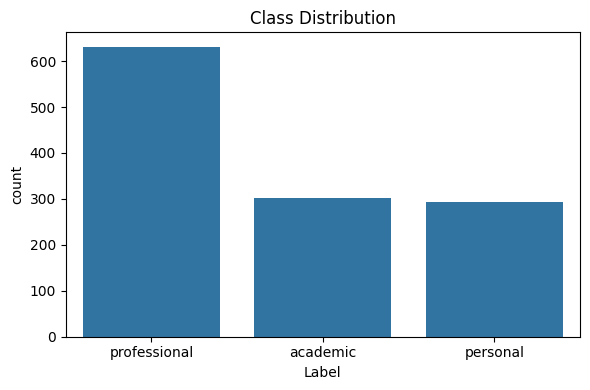

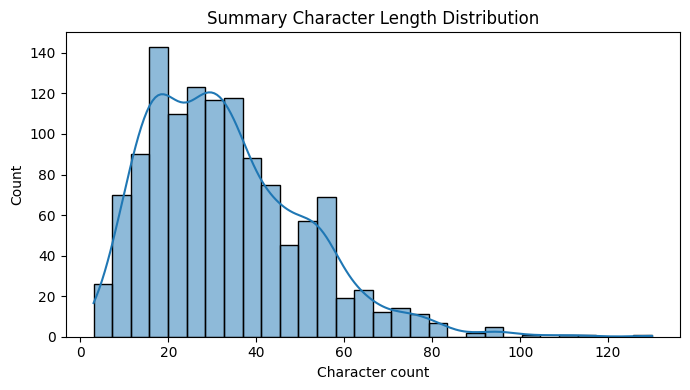

In [97]:
# Lightweight EDA (kept concise)
import matplotlib.pyplot as plt
import seaborn as sns

eda_df = df[['summary', 'Label']].copy()
eda_df['summary'] = eda_df['summary'].fillna('').astype(str)
eda_df['Label'] = eda_df['Label'].astype(str).str.strip()
eda_df = eda_df[eda_df['Label'] != '']

# Simple engineered features for inspection
eda_df['summary_char_len'] = eda_df['summary'].str.len()
eda_df['summary_word_count'] = eda_df['summary'].str.split().str.len()

print('Rows:', len(eda_df))
print('Class distribution:')
print(eda_df['Label'].value_counts())
print()
print('Summary word-count stats:')
display(eda_df['summary_word_count'].describe().to_frame('value').T)

# Visual 1: class balance
plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x='Label', order=eda_df['Label'].value_counts().index)
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

# Visual 2: overall summary length distribution (chars)
plt.figure(figsize=(7, 4))
sns.histplot(data=eda_df, x='summary_char_len', bins=30, kde=True)
plt.title('Summary Character Length Distribution')
plt.xlabel('Character count')
plt.tight_layout()
plt.show()


## 4) Custom Naive Bayes Class

What this section does:
- defines `MyMultinomialNB` from scratch
- learns class priors and token probabilities with smoothing (`alpha`)


In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class MyMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):

        # Convert pandas Series to numpy array so sparse boolean indexing works
        y = np.asarray(y)

        # X is CSR matrix
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        self.class_log_prior_ = np.zeros(n_classes)
        self.feature_log_prob_ = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes_):

            # select rows belonging to class c
            X_c = X[(y == c)]

            # --- class prior ---
            prior = X_c.shape[0] / X.shape[0]
            self.class_log_prior_[idx] = np.log(prior)

            # --- token weights per feature ---
            # IMPORTANT: CSR sum returns matrix, convert with A1
            feature_sum = X_c.sum(axis=0).A1

            total_sum = feature_sum.sum()

            # Laplace smoothing
            smoothed = feature_sum + self.alpha
            denom = total_sum + self.alpha * n_features

            self.feature_log_prob_[idx, :] = np.log(smoothed / denom)

        return self

    def predict_log_proba(self, X):

        # Sparse matrix multiplication works directly
        return X @ self.feature_log_prob_.T + self.class_log_prior_

    def predict(self, X):

        log_probs = self.predict_log_proba(X)
        indices = np.argmax(log_probs, axis=1)
        return self.classes_[indices]


## 5) Baseline Model Run

What this section does:
- trains Naive Bayes with a baseline alpha
- evaluates on the test set

Main outputs:
- confusion matrix
- classification report


In [99]:
model = MyMultinomialNB(alpha=1.0)
model.fit(X_train_vec, y_train)


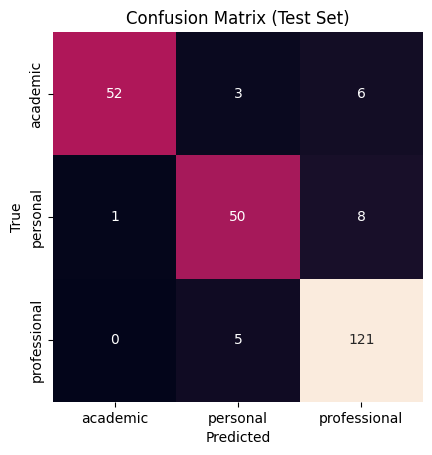

Test label counts:
Label
professional    126
academic         61
personal         59
Name: count, dtype: int64

              precision    recall  f1-score   support

    academic       0.98      0.85      0.91        61
    personal       0.86      0.85      0.85        59
professional       0.90      0.96      0.93       126

    accuracy                           0.91       246
   macro avg       0.91      0.89      0.90       246
weighted avg       0.91      0.91      0.91       246



In [100]:
from sklearn import metrics

pred_labels = model.predict(X_test_vec)

# Use real labels from your dataset (academic/personal/professional)
label_order = sorted(pd.Series(y_test).unique())
cm = metrics.confusion_matrix(y_test, pred_labels, labels=label_order)

sns.heatmap(cm, square=True, annot=True, fmt="d", cbar=False,
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print("Test label counts:")
print(pd.Series(y_test).value_counts())
print()
print(metrics.classification_report(y_test, pred_labels, labels=label_order))


## 6) Interpret Learned Tokens

What this section does:
- shows top tokens per class from learned log-probabilities

This supports interpretation of why the model predicts each class.


In [101]:
# Top tokens per class from learned log-probabilities
top_n = 6
feature_names = np.array(vectorizer.get_feature_names_out())

for class_idx, class_name in enumerate(model.classes_):
    log_probs = model.feature_log_prob_[class_idx]
    top_idx = np.argsort(log_probs)[-top_n:][::-1]
    top_tokens = feature_names[top_idx]
    top_scores = log_probs[top_idx]

    print(f"\nClass: {class_name}")
    for tok, score in zip(top_tokens, top_scores):
        print(f"  {tok:<25} logP={score:.4f}")



Class: academic
  meeting                   logP=-4.0427
  ccp                       logP=-4.1286
  assignment                logP=-4.4130
  deadline                  logP=-4.6168
  session                   logP=-4.6307
  weekly                    logP=-5.0472

Class: personal
  room                      logP=-3.9958
  quiet                     logP=-4.0318
  carl                      logP=-4.0464
  okpala                    logP=-4.0576
  minerva                   logP=-4.2522
  and                       logP=-4.3035

Class: professional
  casing                    logP=-4.1555
  headstart                 logP=-4.4188
  session                   logP=-4.4267
  vertical                  logP=-4.4336
  carl                      logP=-4.4514
  okpala                    logP=-4.7120


## 7) Tune Alpha (Averaged Over Multiple Seeds)

What this section does:
- tests 9 alpha values
- repeats each alpha across multiple random seeds
- reports mean and standard deviation metrics

Main decision rule:
- pick alpha with best **mean Macro-F1**


In [102]:
# Hyperparameter tuning with repeated runs per alpha (average performance)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

alpha_values = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
seeds = [7, 11, 21, 42, 77, 101, 123, 222, 333, 999]

results = []

# Use the same cleaned dataframe as earlier cells
base_df = df[['summary', 'Label']].copy()
base_df['summary'] = base_df['summary'].fillna('').astype(str)
base_df['Label'] = base_df['Label'].astype(str).str.strip()
base_df = base_df[base_df['Label'] != '']

for alpha in alpha_values:
    for seed in seeds:
        # Shuffle first to break temporal ordering, then stratified split
        work_df = base_df.sample(frac=1, random_state=seed).reset_index(drop=True)
        X_text = work_df['summary']
        y = work_df['Label']

        X_train_text, X_test_text, y_train_r, y_test_r = train_test_split(
            X_text, y,
            test_size=0.2,
            random_state=seed,
            stratify=y
        )

        vec = text.TfidfVectorizer()
        X_train_vec_r = vec.fit_transform(X_train_text)
        X_test_vec_r = vec.transform(X_test_text)

        tuned_model = MyMultinomialNB(alpha=alpha)
        tuned_model.fit(X_train_vec_r, y_train_r)
        y_pred_r = tuned_model.predict(X_test_vec_r)

        acc = accuracy_score(y_test_r, y_pred_r)
        macro_f1 = f1_score(y_test_r, y_pred_r, average='macro')

        results.append({
            'alpha': alpha,
            'seed': seed,
            'accuracy': acc,
            'macro_f1': macro_f1
        })

results_df = pd.DataFrame(results)
summary_df = (
    results_df.groupby('alpha', as_index=False)
    .agg(
        mean_accuracy=('accuracy', 'mean'),
        std_accuracy=('accuracy', 'std'),
        mean_macro_f1=('macro_f1', 'mean'),
        std_macro_f1=('macro_f1', 'std')
    )
    .sort_values('mean_macro_f1', ascending=False)
    .reset_index(drop=True)
)

print('Repeated alpha tuning (10 seeds per alpha), sorted by mean Macro-F1:')
display(summary_df)

best_row = summary_df.iloc[0]
print(
    f"Best alpha by mean Macro-F1: {best_row['alpha']} | "
    f"Macro-F1={best_row['mean_macro_f1']:.4f} (+/- {best_row['std_macro_f1']:.4f}), "
    f"Accuracy={best_row['mean_accuracy']:.4f} (+/- {best_row['std_accuracy']:.4f})"
)


Repeated alpha tuning (10 seeds per alpha), sorted by mean Macro-F1:


,alpha,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1
0,0.01,0.926423,0.025383,0.922256,0.027404
1,0.05,0.925610,0.025997,0.921386,0.027967
2,0.10,0.924797,0.027387,0.920444,0.029445
3,1.00,0.919919,0.036108,0.914643,0.040070
4,0.30,0.919512,0.026883,0.914551,0.029828
5,0.50,0.915447,0.029860,0.910270,0.033366
6,2.00,0.893902,0.028193,0.886214,0.032535
7,5.00,0.803252,0.022033,0.775230,0.029215
8,10.00,0.705285,0.015947,0.635183,0.025263


Best alpha by mean Macro-F1: 0.01 | Macro-F1=0.9223 (+/- 0.0274), Accuracy=0.9264 (+/- 0.0254)


## 8) One-Seed 3x3 Alpha Comparison

What this section does:
- uses one fixed split
- draws 9 confusion matrices (one per alpha)

This is used for visual comparison in the report.


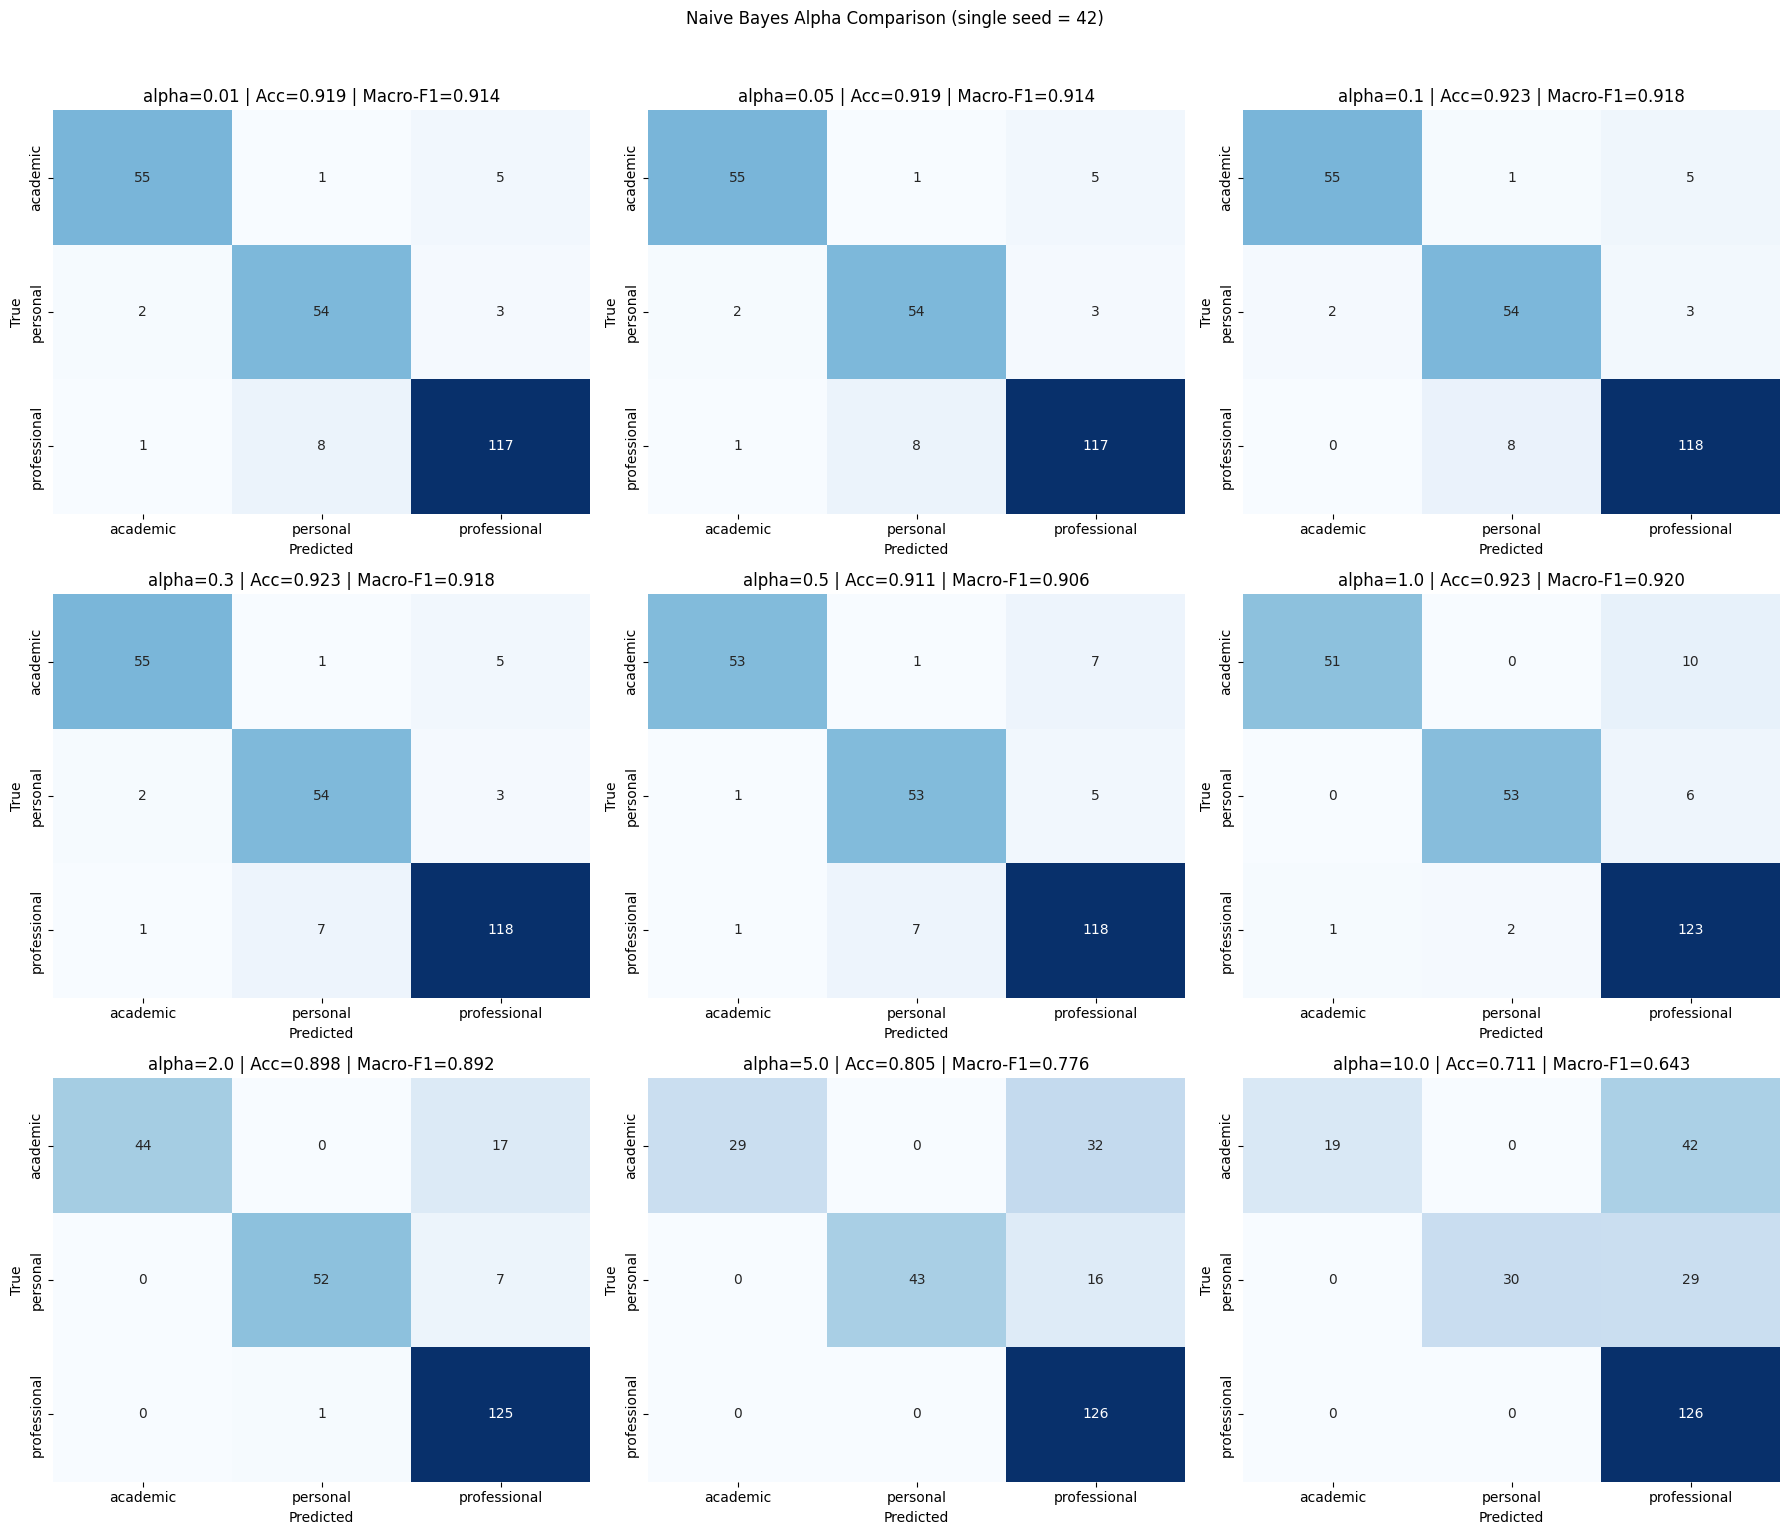

In [103]:
# Single-seed visualization: confusion matrices in a 3x3 grid (one split only)
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

single_seed = 42
alpha_values = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
label_order = sorted(pd.Series(base_df['Label']).unique())

# Build one reproducible split
work_df = base_df.sample(frac=1, random_state=single_seed).reset_index(drop=True)
X_text = work_df['summary']
y = work_df['Label']
X_train_text, X_test_text, y_train_s, y_test_s = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=single_seed,
    stratify=y
)

vec = text.TfidfVectorizer()
X_train_vec_s = vec.fit_transform(X_train_text)
X_test_vec_s = vec.transform(X_test_text)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, alpha in enumerate(alpha_values):
    model_s = MyMultinomialNB(alpha=alpha)
    model_s.fit(X_train_vec_s, y_train_s)
    y_pred_s = model_s.predict(X_test_vec_s)

    acc = accuracy_score(y_test_s, y_pred_s)
    macro_f1 = f1_score(y_test_s, y_pred_s, average='macro')
    cm = confusion_matrix(y_test_s, y_pred_s, labels=label_order)

    sns.heatmap(
        cm,
        ax=axes[i],
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=label_order,
        yticklabels=label_order
    )
    axes[i].set_title(f'alpha={alpha} | Acc={acc:.3f} | Macro-F1={macro_f1:.3f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.suptitle(f'Naive Bayes Alpha Comparison (single seed = {single_seed})', y=1.02)
plt.tight_layout()
plt.show()


## 9) Seed Sensitivity (3x3 Grid)

What this section does:
- keeps split ratio fixed
- changes only random seed
- shows how stable performance is across seeds

This section supports robustness discussion.


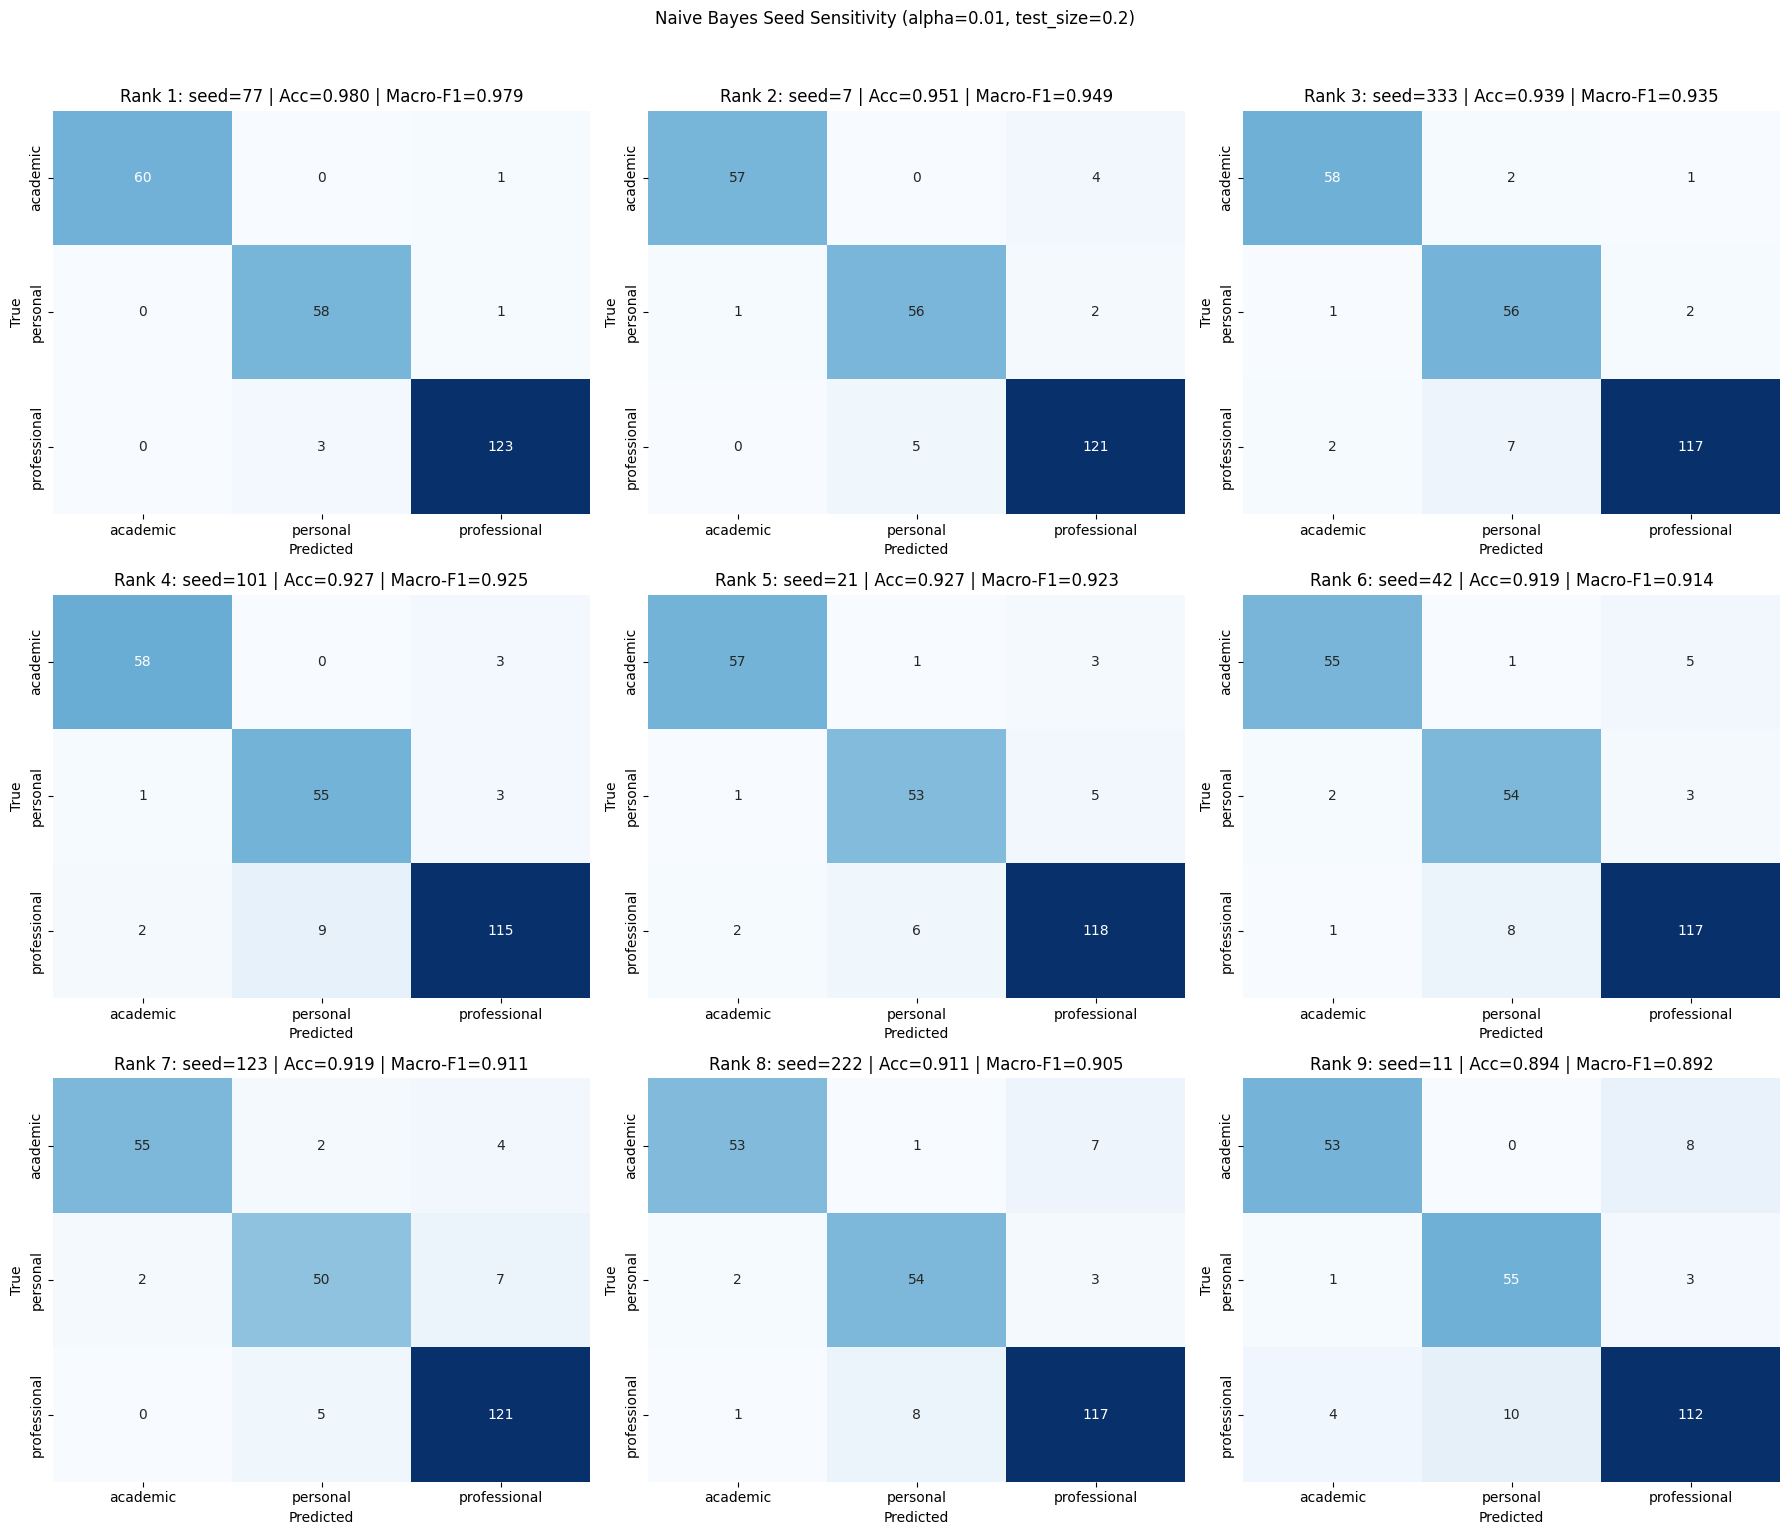

,rank,seed,accuracy,macro_f1
0,1,77,0.979675,0.979494
1,2,7,0.951220,0.949279
2,3,333,0.939024,0.935088
3,4,101,0.926829,0.925434
4,5,21,0.926829,0.923138
5,6,42,0.918699,0.913962
6,7,123,0.918699,0.910752
7,8,222,0.910569,0.905377
8,9,11,0.894309,0.892484


In [104]:
# Seed sensitivity in a 3x3 grid (ordered by Macro-F1, then Accuracy)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

seed_values = [7, 11, 21, 42, 77, 101, 123, 222, 333]  # 9 seeds for 3x3
test_ratio = 0.2
alpha_fixed = 0.01
label_order = sorted(pd.Series(base_df['Label']).unique())

run_results = []

for seed in seed_values:
    work_df = base_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    X_text = work_df['summary']
    y = work_df['Label']

    X_train_text, X_test_text, y_train_s, y_test_s = train_test_split(
        X_text, y,
        test_size=test_ratio,
        random_state=seed,
        stratify=y
    )

    vec = text.TfidfVectorizer()
    X_train_vec_s = vec.fit_transform(X_train_text)
    X_test_vec_s = vec.transform(X_test_text)

    model_s = MyMultinomialNB(alpha=alpha_fixed)
    model_s.fit(X_train_vec_s, y_train_s)
    y_pred_s = model_s.predict(X_test_vec_s)

    acc = accuracy_score(y_test_s, y_pred_s)
    macro_f1 = f1_score(y_test_s, y_pred_s, average='macro')
    cm = confusion_matrix(y_test_s, y_pred_s, labels=label_order)

    run_results.append({
        'seed': seed,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'cm': cm
    })

# Order by performance: primary = macro_f1, secondary = accuracy
run_results = sorted(run_results, key=lambda r: (r['macro_f1'], r['accuracy']), reverse=True)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, r in enumerate(run_results):
    sns.heatmap(
        r['cm'],
        ax=axes[i],
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=label_order,
        yticklabels=label_order
    )
    axes[i].set_title(
        f"Rank {i+1}: seed={r['seed']} | Acc={r['accuracy']:.3f} | Macro-F1={r['macro_f1']:.3f}"
    )
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.suptitle(
    f"Naive Bayes Seed Sensitivity (alpha={alpha_fixed}, test_size={test_ratio})",
    y=1.02
)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame([{
    'rank': i + 1,
    'seed': r['seed'],
    'accuracy': r['accuracy'],
    'macro_f1': r['macro_f1']
} for i, r in enumerate(run_results)])

display(summary_df)


## 10) Class-Wise Error Diagnostics

What this section does:
- plots per-class precision/recall/F1
- identifies weakest class by F1
- identifies most common confusion partner

This section supports limitations and next-step discussion.


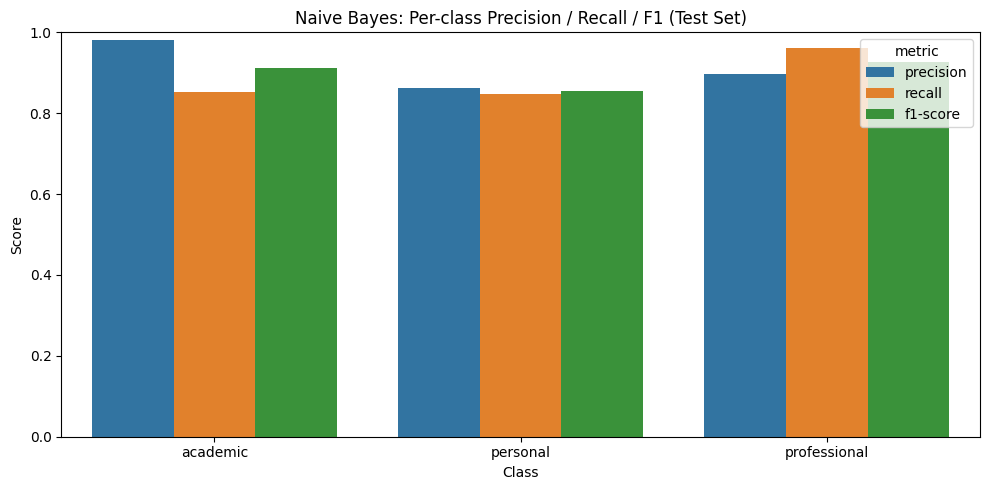

,precision,recall,f1-score
class,,,
academic,0.981132,0.852459,0.912281
personal,0.862069,0.847458,0.854701
professional,0.896296,0.960317,0.927203


Weakest class by F1: personal (F1=0.855)
Most common confusion partner: professional (8 samples from true 'personal' predicted as 'professional')
Correct predictions for 'personal': 50


In [105]:
# Class-wise analysis: precision/recall/F1 and confusion diagnosis
from sklearn.metrics import classification_report, confusion_matrix

# Use baseline test predictions if available; otherwise compute with current split and best alpha
if 'pred_labels' not in globals() or 'y_test' not in globals():
    fallback_model = MyMultinomialNB(alpha=0.01)
    fallback_model.fit(X_train_vec, y_train)
    pred_labels = fallback_model.predict(X_test_vec)

label_order = sorted(pd.Series(y_test).unique())

# 1) Per-class metrics
report = classification_report(y_test, pred_labels, labels=label_order, output_dict=True)
metrics_df = pd.DataFrame(report).T.loc[label_order, ['precision', 'recall', 'f1-score']]
metrics_df.index.name = 'class'
metrics_long = metrics_df.reset_index().melt(id_vars='class', var_name='metric', value_name='score')

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_long, x='class', y='score', hue='metric')
plt.ylim(0, 1.0)
plt.title('Naive Bayes: Per-class Precision / Recall / F1 (Test Set)')
plt.ylabel('Score')
plt.xlabel('Class')
plt.tight_layout()
plt.show()

display(metrics_df)

# 2) Weakest class + most common confusion partner
weakest_class = metrics_df['f1-score'].idxmin()
cm = confusion_matrix(y_test, pred_labels, labels=label_order)
cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)

row = cm_df.loc[weakest_class].copy()
correct = row[weakest_class]
row_no_diag = row.drop(index=weakest_class)
confusion_partner = row_no_diag.idxmax()
confusion_count = int(row_no_diag.max())

print(f"Weakest class by F1: {weakest_class} (F1={metrics_df.loc[weakest_class, 'f1-score']:.3f})")
print(
    f"Most common confusion partner: {confusion_partner} "
    f"({confusion_count} samples from true '{weakest_class}' predicted as '{confusion_partner}')"
)
print(f"Correct predictions for '{weakest_class}': {int(correct)}")
